# Payload-Range Chart Tutorial
## EAE 130B, SQ 2026 — Boeing 787-8 Dreamliner

Last edit: Huanglun Adam. Zhu — 4/28/2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1  What is a Payload-Range Chart?

Every kilogram of payload you add removes a kilogram of fuel.
The payload-range chart maps out this trade-off by asking:
*For a given payload, how far can the aircraft fly?*

The fundamental constraint is the **Maximum Take-Off Weight (MTOW)**:

$$TOW = OEW + W_P + W_F \leq MTOW$$

| Symbol | Meaning |
|---|---|
| OEW | Operating Empty Weight (airframe, engines, crew, oil) |
| $W_P$ | Payload (passengers + cargo) |
| $W_F$ | Fuel (mission fuel **including** reserve) |

Rearranging: $W_F = MTOW - OEW - W_P$. More payload → less fuel → shorter range.

### The five chart points

| Point | Payload | Fuel loaded | Binding constraint |
|:---:|---|---|---|
| **A** | Max (MPW) | 0 | Zero-range anchor |
| **B** | Max (MPW) | MTOW − OEW − MPW | MTOW (tanks not full) |
| **C** | Reduced | Max (MFW) | MTOW + full tanks |
| **D** | 0 | Max (MFW) | Below MTOW (ferry) |
| **T** | Design (DPW) | MTOW − OEW − DPW | Design / target mission |

Connect **A → B → C → D** for the envelope. Plot **T** inside it.

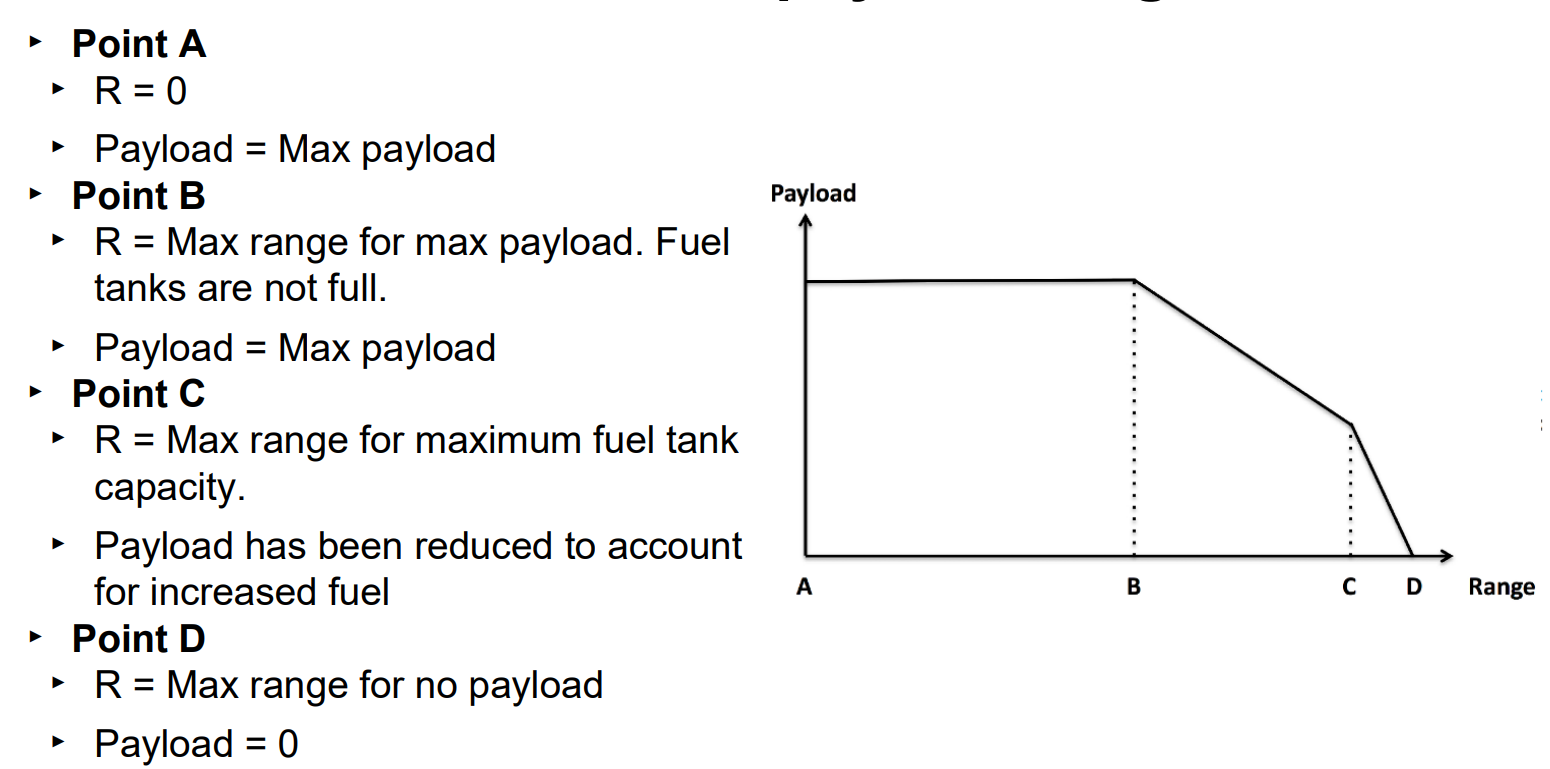

## 2  The Breguet Range Equation (Jets)

For a jet cruising at **constant altitude** with **constant $C_L$**, speed decreases as fuel burns ($V = \sqrt{2W/\rho S C_L}$). Integrating the fuel-burn rate gives:

$$\boxed{R = 2\sqrt{\frac{2}{\rho_\infty S}}\;\frac{1}{c_t}\;\frac{C_L^{1/2}}{C_D}\left(\sqrt{W_0} - \sqrt{W_1}\right)}$$

### Inputs you need

| Symbol | Meaning | Unit | Where to find it |
|---|---|---|---|
| $\rho_\infty$ | Air density at cruise altitude | slug/ft³ | Standard atmosphere table |
| $S$ | Wing reference area | ft² | Aircraft geometry |
| $C_L$ | Cruise lift coefficient | — | Aero analysis |
| $C_D$ | Cruise drag coefficient | — | Aero analysis |
| $c_t$ | Thrust-specific fuel consumption (TSFC) | lb/(lb·s) | Engine data sheet |
| $W_0$ | Weight at **start** of cruise | lb | See table below |
| $W_1$ | Weight at **end** of cruise | lb | See table below |

### How to find W₀ and W₁ for each point

$W_0 \approx$ takeoff weight.  
$W_1 = W_0 - W_{F,\text{usable}}$, where usable fuel = fuel loaded − reserve.

**Reserve fuel** ($W_{\text{res}} = \text{RFF} \times W_F$) stays on board at landing — it is not available for range.
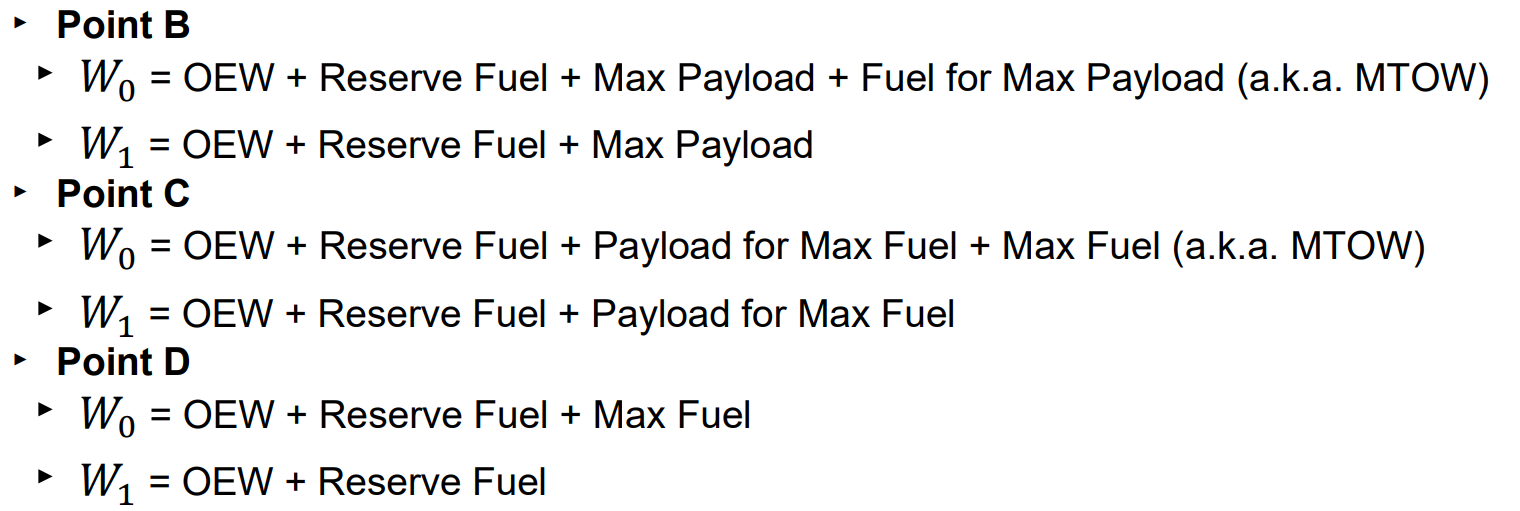
| Point | $W_0$ | $W_1$ |
|:---:|---|---|
| B | MTOW | OEW + MPW + $W_{\text{res}}$ |
| C | MTOW | OEW + Payload$_C$ + $W_{\text{res}}$ |
| D | OEW + MFW *(below MTOW)* | OEW + $W_{\text{res}}$ |
| T | MTOW | OEW + DPW + $W_{\text{res}}$ |



## 3  Input: Aircraft Weight Data

Enter the Boeing 787-8 parameters below. **For your own aircraft, replace every value in this cell.**

In [ ]:
# ── Boeing 787-8 weight data ───────────────────────────────────────────── FROM INTERNET SOURCES ────────────────────────────────────────────────
MTOW = 502500    # lb  Maximum takeoff weight
OEW  = 239200    # lb  Operating empty weight
MZFW = 340000    # lb  Maximum zero-fuel weight (structural limit! of the aircraft)
# Calculate maximum payload weight = Max Zero Fuel Weight - Operating Empty Weight
MPW = MZFW - OEW       # Maximum Payload Weight  (MZFW structural limit)

# Maximum fuel capacity ───────────────────────────────────────────── FROM INTERNET SOURCES ────────────────────────────────────────────────
fuel_capacity_gal   = 32940    # US gallons
fuel_density_lb_lit = 1.744     # lb/liter  (Jet-A)
liters_per_gal      = 3.78541
# Calculate maximum fuel weight
MFW = fuel_capacity_gal * liters_per_gal * fuel_density_lb_lit

# Passengers ───────────────────────────────────────────── FROM INTERNET SOURCES ────────────────────────────────────────────────
n_pax = 224    # number of passengers
w_pax = 210    # lb per passenger (body + carry-on)
# Calculate design payload weight (full passenger load)
DPW = n_pax * w_pax    # Design Payload Weight   (full pax load)

# Reserve fuel fraction — kept on board at landing (not burned for range)
RFF = 0.06   # 6 %

print(f'  MTOW = {MTOW:>10,} lb')
print(f'  OEW  = {OEW:>10,} lb')
print(f'  Max Zero Fuel Weight = {MZFW:>10,} lb')
print(f'  Max Fuel Weight  = {MFW:>10,.0f} lb   ({fuel_capacity_gal:,} US gal)')
print(f'  Max Payload Weight  = {MPW:>10,} lb   (= MZFW - OEW)')
print(f'  Design Payload Weight  = {DPW:>10,} lb   ({n_pax} pax x {w_pax} lb)')
print()
print(f'  Weight budget (MTOW - OEW) = {MTOW-OEW:,} lb  <- shared by payload + fuel')

  MTOW =    502,500 lb
  OEW  =    239,200 lb
  Max Zero Fuel Weight =    340,000 lb
  Max Fuel Weight  =    217,462 lb   (32,940 US gal)
  Max Payload Weight  =    100,800 lb   (= MZFW - OEW)
  Design Payload Weight  =     47,040 lb   (224 pax x 210 lb)

  Weight budget (MTOW - OEW) = 263,300 lb  <- shared by payload + fuel


## 4  Input: Cruise Parameters

Enter aerodynamic and engine data for the cruise segment. **For your own aircraft, replace every value in this cell.**

In [ ]:
# ── Boeing 787-8 cruise parameters ────────────────────────────────────── FROM INTERNET SOURCES ────────────────────────────────────────────────
rho_c  = 7.382e-4   # slug/ft3  air density at 35,000 ft (ISA)
S      = 3501.0     # ft2       wing reference area
CL     = 0.52       #           cruise lift coefficient
LD     = 18.0       #           cruise L/D  (lift-to-drag ratio)
CD     = CL / LD    #           cruise drag coefficient  (= 0.026)
TSFC   = 0.53       # lb/lb/hr  thrust-specific fuel consumption (GEnx-1B)
ct     = TSFC / 3600            # lb/lb/s   (convert for the Breguet integral)

print(f'  Altitude : 35,000 ft  ->  rho = {rho_c:.4e} slug/ft3')
print(f'  S        : {S:,.0f} ft2')
print(f'  CL = {CL},  CD = {CD:.5f},  L/D = {LD}')
print(f'  TSFC     : {TSFC} lb/lb/hr  =  {ct:.4e} lb/lb/s')


  Altitude : 35,000 ft  ->  rho = 7.3820e-04 slug/ft3
  S        : 3,501 ft2
  CL = 0.52,  CD = 0.02889,  L/D = 18.0
  TSFC     : 0.53 lb/lb/hr  =  1.4722e-04 lb/lb/s


Recall:

For a jet cruising at **constant altitude** with **constant $C_L$**, speed decreases as fuel burns ($V = \sqrt{2W/\rho S C_L}$). Integrating the fuel-burn rate gives:

$$\boxed{R = 2\sqrt{\frac{2}{\rho_\infty S}}\;\frac{1}{c_t}\;\frac{C_L^{1/2}}{C_D}\left(\sqrt{W_0} - \sqrt{W_1}\right)}$$


In [15]:

# ── Breguet range function ────────────────────────────────────────────────
def breguet(W0, W1):
    """
    Jet Breguet range (constant altitude, constant CL).
    R = 2*sqrt(2/rho*S) * (1/ct) * (CL^0.5/CD) * (sqrt(W0) - sqrt(W1))
    W0, W1 in lb  ->  returns range in nautical miles
    """
    # FT to NM conversion factor
    FT_PER_NM = 6076.12  # ft / nautical mile

    # Compute range in feet using the Breguet formula
    R_ft = (2 * np.sqrt(2 / (rho_c * S))
              * (1 / ct)
              * (CL**0.5 / CD)
              * (W0**0.5 - W1**0.5))
    range_nm = R_ft / FT_PER_NM # convert ft to NM

    return range_nm

## 5  Point-by-Point Calculations

Each subsection below:
1. States the physical scenario
2. Builds the weight stack to get $W_0$ and $W_1$
3. Calls `breguet(W0, W1)` to get the range

### Point A — Zero Range, Maximum Payload

**Scenario:** Aircraft loaded to the maximum payload limit. No fuel for range.

$$W_0 = OEW + MPW, \quad W_1 = W_0 \quad (\text{nothing burned}), \quad R = 0$$

This is the **left anchor** of the payload-range envelope. No Breguet calculation needed — range is zero by definition.

In [16]:
payload_A = MPW
range_A   = 0

print(f'Point A')
print(f'  Payload = {payload_A:,} lb  (= MPW)')
print(f'  Range   = {range_A} nm')

Point A
  Payload = 100,800 lb  (= MPW)
  Range   = 0 nm


### Point B — Harmonic Range (Maximum Payload at MTOW)
Recall:

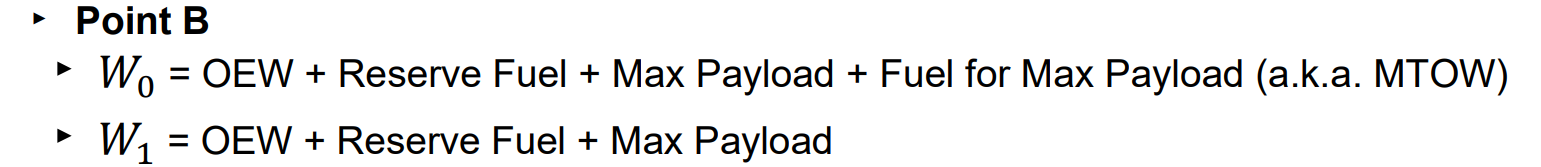

**Scenario:** Fly as far as possible while carrying **maximum payload**.
MTOW is the binding constraint, so fuel = whatever weight is left after loading MPW.
Tanks are **not** full.

| Step | Formula | Notes |
|---|---|---|
| Fuel loaded | $W_F = MTOW - OEW - MPW$ | fills the MTOW budget |
| Reserve | $W_{\text{res}} = RFF \times W_F$ | stays aboard at landing |
| $W_0$ | $= MTOW$ | take-off at max gross weight |
| $W_1$ | $= OEW + MPW + W_{\text{res}}$ | arrive with payload + reserve only |
| Range | $breguet(W_0, W_1)$ | |

*This range is called the **harmonic range** — the maximum range at full payload.*

In [17]:
FW_B      = MTOW - OEW - MPW      # fuel that fits after max payload, at MTOW
W_res_B   = RFF * FW_B            # reserve (not burned for range)
payload_B = MPW
W0_B      = MTOW
W1_B      = OEW + MPW + W_res_B
range_B   = breguet(W0_B, W1_B)

print(f'Point B')
print(f'  Fuel loaded  = MTOW - OEW - MPW = {MTOW} - {OEW} - {MPW} = {FW_B:,} lb')
print(f'  Reserve      = {RFF:.0%} x {FW_B:,} = {W_res_B:,.0f} lb')
print(f'  W0 = MTOW                       = {W0_B:,} lb')
print(f'  W1 = OEW + MPW + Wres           = {OEW} + {MPW} + {W_res_B:.0f} = {W1_B:,.0f} lb')
print(f'  Payload = {payload_B:,} lb')
print(f'  Range   = {range_B:,.0f} nm')

Point B
  Fuel loaded  = MTOW - OEW - MPW = 502500 - 239200 - 100800 = 162,500 lb
  Reserve      = 6% x 162,500 = 9,750 lb
  W0 = MTOW                       = 502,500 lb
  W1 = OEW + MPW + Wres           = 239200 + 100800 + 9750 = 349,750 lb
  Payload = 100,800 lb
  Range   = 5,767 nm


### Point C — Maximum-Fuel Range

Recall:

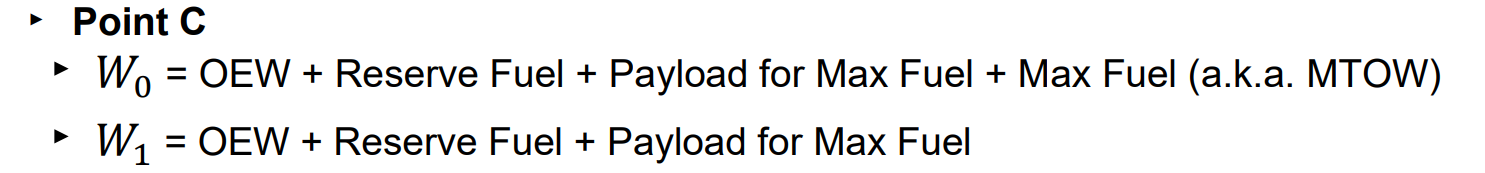

**Scenario:** Tanks are **full** (MFW). To stay within MTOW, payload must shrink.

| Step | Formula | Notes |
|---|---|---|
| Fuel loaded | $W_F = MFW$ | tanks are full |
| Payload | $W_{P,C} = MTOW - OEW - MFW$ | reduced to fit full tanks at MTOW |
| Reserve | $W_{\text{res}} = RFF \times MFW$ | |
| $W_0$ | $= MTOW$ | still at max gross weight |
| $W_1$ | $= OEW + W_{P,C} + W_{\text{res}}$ | |
| Range | $breguet(W_0, W_1)$ | |

*Full tanks is the binding constraint; payload is traded away for extra fuel.*

In [18]:
FW_C      = MFW
payload_C = MTOW - OEW - MFW      # payload reduced to stay within MTOW
W_res_C   = RFF * FW_C
W0_C      = MTOW
W1_C      = OEW + payload_C + W_res_C
range_C   = breguet(W0_C, W1_C)

print(f'Point C')
print(f'  Fuel loaded  = MFW             = {FW_C:,.0f} lb')
print(f'  Payload_C    = MTOW-OEW-MFW    = {MTOW}-{OEW}-{FW_C:.0f} = {payload_C:,.0f} lb  (reduced!)')
print(f'  Reserve      = {RFF:.0%} x {FW_C:,.0f} = {W_res_C:,.0f} lb')
print(f'  W0 = MTOW                      = {W0_C:,} lb')
print(f'  W1 = OEW + Payload_C + Wres    = {OEW} + {payload_C:.0f} + {W_res_C:.0f} = {W1_C:,.0f} lb')
print(f'  Payload = {payload_C:,.0f} lb')
print(f'  Range   = {range_C:,.0f} nm')

Point C
  Fuel loaded  = MFW             = 217,462 lb
  Payload_C    = MTOW-OEW-MFW    = 502500-239200-217462 = 45,838 lb  (reduced!)
  Reserve      = 6% x 217,462 = 13,048 lb
  W0 = MTOW                      = 502,500 lb
  W1 = OEW + Payload_C + Wres    = 239200 + 45838 + 13048 = 298,086 lb
  Payload = 45,838 lb
  Range   = 7,997 nm


### Point D — Ferry Range (Zero Payload)

Recall:

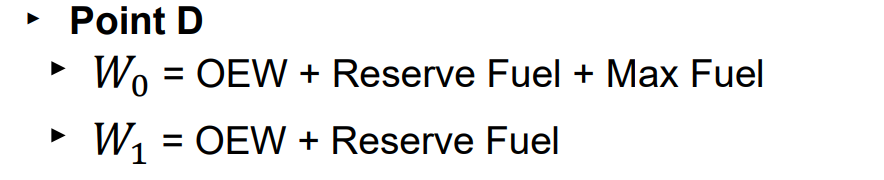

**Scenario:** No payload, full tanks. TOW is **below MTOW** — lighter aircraft, better fuel efficiency, longest range.

| Step | Formula | Notes |
|---|---|---|
| Fuel loaded | $W_F = MFW$ | tanks are full |
| Payload | 0 | no useful load |
| Reserve | $W_{\text{res}} = RFF \times MFW$ | |
| $W_0$ | $= OEW + MFW$ | **less than MTOW** (no payload!) |
| $W_1$ | $= OEW + W_{\text{res}}$ | arrive with empty payload bay + reserve |
| Range | $breguet(W_0, W_1)$ | |

*Same fuel as Point C but lighter take-off weight → more range.*

In [19]:
FW_D      = MFW
payload_D = 0
W_res_D   = RFF * FW_D
W0_D      = OEW + FW_D            # below MTOW — no payload means lighter aircraft
W1_D      = OEW + W_res_D
range_D   = breguet(W0_D, W1_D)

print(f'Point D')
print(f'  Fuel loaded  = MFW             = {FW_D:,.0f} lb')
print(f'  W0 = OEW + MFW                 = {OEW} + {FW_D:.0f} = {W0_D:,.0f} lb  (< MTOW = {MTOW:,})')
print(f'  Reserve      = {RFF:.0%} x {FW_D:,.0f} = {W_res_D:,.0f} lb')
print(f'  W1 = OEW + Wres                = {OEW} + {W_res_D:.0f} = {W1_D:,.0f} lb')
print(f'  Payload = {payload_D} lb')
print(f'  Range   = {range_D:,.0f} nm')

Point D
  Fuel loaded  = MFW             = 217,462 lb
  W0 = OEW + MFW                 = 239200 + 217462 = 456,662 lb  (< MTOW = 502,500)
  Reserve      = 6% x 217,462 = 13,048 lb
  W1 = OEW + Wres                = 239200 + 13048 = 252,248 lb
  Payload = 0 lb
  Range   = 8,519 nm


### Point T — Design / Target Mission

**Scenario:** Full design passenger load (DPW) at MTOW. This is your team's actual operating point (it must fall **inside** the A→B→C→D envelope).

| Step | Formula | Notes |
|---|---|---|
| Fuel loaded | $W_F = MTOW - OEW - DPW$ | fills remaining MTOW budget |
| Reserve | $W_{\text{res}} = RFF \times W_F$ | |
| $W_0$ | $= MTOW$ | |
| $W_1$ | $= OEW + DPW + W_{\text{res}}$ | |
| Range | $breguet(W_0, W_1)$ | |

In [22]:
FW_T      = MTOW - OEW - DPW
W_res_T   = RFF * FW_T
payload_T = DPW
W0_T      = MTOW
W1_T      = OEW + DPW + W_res_T
range_T   = breguet(W0_T, W1_T)

print(f'Point T')
print(f'  Fuel loaded  = MTOW-OEW-DPW    = {MTOW}-{OEW}-{DPW} = {FW_T:,} lb')
print(f'  Reserve      = {RFF:.0%} x {FW_T:,} = {W_res_T:,.0f} lb')
print(f'  W0 = MTOW                       = {W0_T:,} lb')
print(f'  W1 = OEW + DPW + Wres           = {OEW} + {DPW} + {W_res_T:.0f} = {W1_T:,.0f} lb')
print(f'  Payload = {payload_T:,} lb  ({n_pax} pax)')
print(f'  Range   = {range_T:,.0f} nm')

Point T
  Fuel loaded  = MTOW-OEW-DPW    = 502500-239200-47040 = 216,260 lb
  Reserve      = 6% x 216,260 = 12,976 lb
  W0 = MTOW                       = 502,500 lb
  W1 = OEW + DPW + Wres           = 239200 + 47040 + 12976 = 299,216 lb
  Payload = 47,040 lb  (224 pax)
  Range   = 7,947 nm


## 6  Summary

In [23]:
summary = pd.DataFrame({
    'Point': ['A', 'B', 'C', 'D', 'T'],
    'Description': [
        'Zero range / max payload',
        'Harmonic range (max payload @ MTOW)',
        'Max-fuel range (full tanks @ MTOW)',
        'Ferry range (zero payload)',
        'Design / target mission',
    ],
    'Payload (lb)': [int(payload_A), int(payload_B), int(round(payload_C)),
                     int(payload_D), int(payload_T)],
    'TOW (lb)':     [int(OEW+payload_A), int(W0_B), int(W0_C),
                     int(round(W0_D)), int(W0_T)],
    'Fuel (lb)':    [0, int(FW_B), int(round(FW_C)), int(round(FW_D)), int(FW_T)],
    'W0 (lb)':      [int(OEW+payload_A), int(W0_B), int(W0_C),
                     int(round(W0_D)), int(W0_T)],
    'W1 (lb)':      [int(OEW+payload_A), int(round(W1_B)), int(round(W1_C)),
                     int(round(W1_D)), int(round(W1_T))],
    'Range (nm)':   [int(range_A), int(round(range_B)), int(round(range_C)),
                     int(round(range_D)), int(round(range_T))],
})
summary

,Point,Description,Payload (lb),TOW (lb),Fuel (lb),W0 (lb),W1 (lb),Range (nm)
0,A,Zero range / max payload,100800,340000,0,340000,340000,0
1,B,Harmonic range (max payload @ MTOW),100800,502500,162500,502500,349750,5767
2,C,Max-fuel range (full tanks @ MTOW),45838,502500,217462,502500,298086,7997
3,D,Ferry range (zero payload),0,456662,217462,456662,252248,8519
4,T,Design / target mission,47040,502500,216260,502500,299216,7947


## 7  Payload-Range Chart

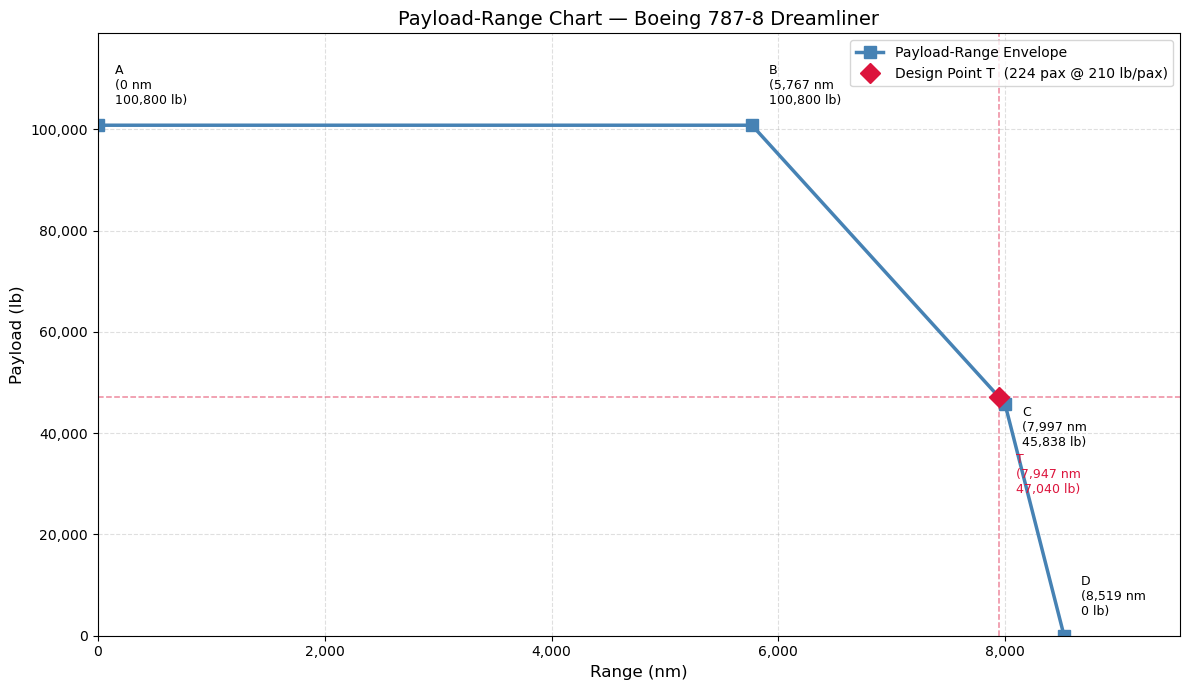

In [27]:
fig, ax = plt.subplots(figsize=(12, 7))

# Envelope A -> B -> C -> D
env_r = [range_A,   range_B,   range_C,   range_D]
env_p = [payload_A, payload_B, payload_C, payload_D]
ax.plot(env_r, env_p, color='steelblue', linewidth=2.5,
        marker='s', markersize=8, label='Payload-Range Envelope')

# Design point T
ax.plot(range_T, payload_T, color='crimson', marker='D',
        markersize=10, linestyle='None',
        label=f'Design Point T  ({n_pax} pax @ {w_pax} lb/pax)')
ax.axhline(payload_T, color='crimson', linestyle='--', linewidth=1.1, alpha=0.5)
ax.axvline(range_T,   color='crimson', linestyle='--', linewidth=1.1, alpha=0.5)

# Annotate envelope points
offsets = {'A': (150, 3500), 'B': (150, 3500),
           'C': (150, -9000), 'D': (150, 3500)}
for pt, r, p in zip(['A','B','C','D'], env_r, env_p):
    dx, dy = offsets[pt]
    ax.annotate(f'{pt}\n({int(round(r)):,} nm\n{int(round(p)):,} lb)',
                xy=(r, p), xytext=(r+dx, p+dy), fontsize=9, va='bottom')

ax.annotate(f'T\n({int(round(range_T)):,} nm\n{int(payload_T):,} lb)',
            xy=(range_T, payload_T),
            xytext=(range_T+150, payload_T-11000),
            fontsize=9, color='crimson', va='top')

ax.set_xlabel('Range (nm)', fontsize=12)
ax.set_ylabel('Payload (lb)', fontsize=12)
ax.set_title('Payload-Range Chart — Boeing 787-8 Dreamliner', fontsize=14)
ax.set_xlim(0, max(env_r)*1.12)
ax.set_ylim(0, MPW*1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()